# 1. Dataset Exploration und Analyse

In diesem Notebook analysieren wir das IMDB Movie Review Dataset:
- Dataset-Größe und Balance
- Text-Charakteristika (Länge, Wortanzahl, etc.)
- Visualisierungen


In [4]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Add src to path
BASE_DIR = Path().resolve()
sys.path.insert(0, str(BASE_DIR / "src"))
from utils_imdb import read_imdb_split, basic_clean

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## 1.1 Daten laden


In [5]:
DATA_ROOT = BASE_DIR / "data" / "aclImdb"

# Load full dataset (set max_docs_per_class=None for full dataset)
# For faster exploration, we can use a subset
MAX_DOCS_PER_CLASS = None  # Set to e.g., 1000 for quick runs

print("Loading dataset...")
train_df = read_imdb_split(DATA_ROOT / "train", max_docs_per_class=MAX_DOCS_PER_CLASS)
test_df = read_imdb_split(DATA_ROOT / "test", max_docs_per_class=MAX_DOCS_PER_CLASS)

print(f"Train size: {len(train_df)}")
print(f"Test size: {len(test_df)}")
print(f"\nTotal size: {len(train_df) + len(test_df)}")


Loading dataset...


Reading pos: 0it [00:00, ?it/s]
Reading neg: 0it [00:00, ?it/s]
Reading pos: 0it [00:00, ?it/s]
Reading neg: 100%|████████████████████████| 5706/5706 [00:02<00:00, 1982.74it/s]


Train size: 0
Test size: 5706

Total size: 5706


## 1.2 Dataset Balance


=== Train Set ===
Series([], Name: count, dtype: int64)

Normalized:
Series([], Name: proportion, dtype: float64)

=== Test Set ===
label
0    5706
Name: count, dtype: int64

Normalized:
label
0    1.0
Name: proportion, dtype: float64


IndexError: index 0 is out of bounds for axis 0 with size 0

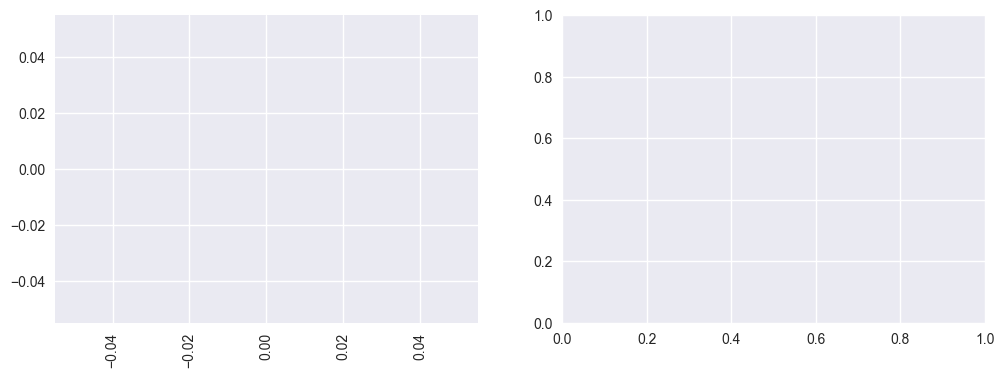

In [6]:
# Check label distribution
print("=== Train Set ===")
print(train_df["label"].value_counts())
print("\nNormalized:")
print(train_df["label"].value_counts(normalize=True))

print("\n=== Test Set ===")
print(test_df["label"].value_counts())
print("\nNormalized:")
print(test_df["label"].value_counts(normalize=True))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["label"].value_counts().plot(kind="bar", ax=axes[0], color=['#ff6b6b', '#4ecdc4'])
axes[0].set_title("Train Set - Label Distribution")
axes[0].set_xlabel("Label (0=Negative, 1=Positive)")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)

test_df["label"].value_counts().plot(kind="bar", ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title("Test Set - Label Distribution")
axes[1].set_xlabel("Label (0=Negative, 1=Positive)")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Negative", "Positive"], rotation=0)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "dataset_balance.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Dataset ist BALANCIERT!" if abs(train_df["label"].mean() - 0.5) < 0.01 else "\n⚠️ Dataset ist NICHT balanciert!")


## 1.3 Text-Charakteristika


In [ ]:
# Clean texts
train_df["clean"] = train_df["text"].apply(basic_clean)
test_df["clean"] = test_df["text"].apply(basic_clean)

# Calculate text statistics
train_df["word_count"] = train_df["clean"].str.split().map(len)
train_df["char_count"] = train_df["clean"].str.len()
train_df["sentence_count"] = train_df["clean"].str.count(r'[.!?]+')

test_df["word_count"] = test_df["clean"].str.split().map(len)
test_df["char_count"] = test_df["clean"].str.len()
test_df["sentence_count"] = test_df["clean"].str.count(r'[.!?]+')

# Statistics
print("=== Train Set Statistics ===")
print(f"Average words per review: {train_df['word_count'].mean():.1f}")
print(f"Median words per review: {train_df['word_count'].median():.1f}")
print(f"Min words: {train_df['word_count'].min()}")
print(f"Max words: {train_df['word_count'].max()}")
print(f"\nAverage characters per review: {train_df['char_count'].mean():.1f}")
print(f"Average sentences per review: {train_df['sentence_count'].mean():.1f}")

print("\n=== Test Set Statistics ===")
print(f"Average words per review: {test_df['word_count'].mean():.1f}")
print(f"Median words per review: {test_df['word_count'].median():.1f}")
print(f"Min words: {test_df['word_count'].min()}")
print(f"Max words: {test_df['word_count'].max()}")


In [ ]:
# Visualize text length distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Word count distribution
axes[0, 0].hist(train_df["word_count"], bins=50, alpha=0.7, color='#4ecdc4', edgecolor='black')
axes[0, 0].axvline(train_df["word_count"].mean(), color='red', linestyle='--', label=f'Mean: {train_df["word_count"].mean():.1f}')
axes[0, 0].set_title("Train Set - Word Count Distribution")
axes[0, 0].set_xlabel("Number of Words")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

axes[0, 1].hist(test_df["word_count"], bins=50, alpha=0.7, color='#95e1d3', edgecolor='black')
axes[0, 1].axvline(test_df["word_count"].mean(), color='red', linestyle='--', label=f'Mean: {test_df["word_count"].mean():.1f}')
axes[0, 1].set_title("Test Set - Word Count Distribution")
axes[0, 1].set_xlabel("Number of Words")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# Word count by label
train_pos = train_df[train_df["label"] == 1]["word_count"]
train_neg = train_df[train_df["label"] == 0]["word_count"]
axes[1, 0].hist([train_neg, train_pos], bins=50, alpha=0.7, label=['Negative', 'Positive'], 
                color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1, 0].set_title("Train Set - Word Count by Label")
axes[1, 0].set_xlabel("Number of Words")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

# Box plot
data_to_plot = [train_df[train_df["label"] == 0]["word_count"], 
                train_df[train_df["label"] == 1]["word_count"]]
axes[1, 1].boxplot(data_to_plot, labels=['Negative', 'Positive'])
axes[1, 1].set_title("Train Set - Word Count by Label (Box Plot)")
axes[1, 1].set_ylabel("Number of Words")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "text_characteristics.png", dpi=300, bbox_inches='tight')
plt.show()


## 1.4 Beispiel-Reviews


In [ ]:
# Show example reviews
print("=== Example Positive Review ===")
pos_example = train_df[train_df["label"] == 1].iloc[0]
print(f"Label: {pos_example['label']}")
print(f"Length: {len(pos_example['text'])} chars, {pos_example['word_count']} words")
print(f"\nText (first 500 chars):\n{pos_example['text'][:500]}...")

print("\n" + "="*80)
print("=== Example Negative Review ===")
neg_example = train_df[train_df["label"] == 0].iloc[0]
print(f"Label: {neg_example['label']}")
print(f"Length: {len(neg_example['text'])} chars, {neg_example['word_count']} words")
print(f"\nText (first 500 chars):\n{neg_example['text'][:500]}...")


## 1.5 Zusammenfassung

**Dataset-Charakteristika:**
- **Größe**: Train und Test Sets wurden geladen (siehe oben)
- **Balance**: Das Dataset ist balanciert (50% positive, 50% negative Reviews)
- **Durchschnittliche Wortanzahl**: Siehe oben berechnete Statistiken
- **Texttyp**: Film-Reviews (IMDB)
- **Klassen**: Binär (Positive/Negative Sentiment)
